# CounterStrike-1K — Quickstart

This notebook runs end-to-end against the public preview repo. No environment variables, no config files. Open and run all.

**What you'll see**: 1) browse the manifest, 2) decode one sample, 3) inspect actions/state, 4) watch the video, 5) **HUD overlay to verify action–video alignment**, 6) load all 10 synchronized POVs of one round.

**Setup** (run once):

```bash
uv add datasets "counterstrike1k @ git+https://github.com/AnirudhhRamesh/CounterStrike-1K" av matplotlib pillow pandas
```

Or with pip: `pip install datasets "counterstrike1k @ git+https://github.com/AnirudhhRamesh/CounterStrike-1K" av matplotlib pillow pandas`

## 1. Browse the manifest

The manifest is a small Parquet file (~25 MB) listing every released POV sample with split, map, weapon, kill counts, and round/match grouping. Read it with pandas — no media is downloaded here.

In [1]:
import pandas as pd
from huggingface_hub import hf_hub_download

manifest = pd.read_parquet(hf_hub_download(
    "ArnieRamesh/CounterStrike-1K", "manifest.parquet", repo_type="dataset",
))
print(f"{len(manifest):,} POV samples across all splits")
manifest.head()[["sample_key", "split", "map_slug", "round_id", "pov_idx", "duration_s", "frames"]]

/Users/anirudhh/projects/ml/cs2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


73,470 POV samples across all splits


,sample_key,split,map_slug,round_id,pov_idx,duration_s,frames
0,match_008a5aa86366__r001__p00,train,nuke,match_008a5aa86366__r001,0,146.281250,4681
1,match_008a5aa86366__r001__p01,train,nuke,match_008a5aa86366__r001,1,146.281250,4681
2,match_008a5aa86366__r001__p02,train,nuke,match_008a5aa86366__r001,2,94.390625,3020
3,match_008a5aa86366__r001__p03,train,nuke,match_008a5aa86366__r001,3,146.281250,4681
4,match_008a5aa86366__r001__p04,train,nuke,match_008a5aa86366__r001,4,146.281250,4681


Boolean masks give you fast, vectorized filtering — much faster than `.filter(lambda)`:

In [2]:
mirage_train = manifest[(manifest["map_slug"] == "mirage") & (manifest["split"] == "train")]
print(f"{len(mirage_train):,} Mirage train clips")
manifest["map_slug"].value_counts()

10,710 Mirage train clips


map_slug
ancient     12610
mirage      11920
anubis      11550
nuke         9960
dust2        9410
inferno      9230
overpass     8790
Name: count, dtype: int64

## 2. Stream one sample

We stream from the small preview repo (no full download). `decode_sample` turns one shard sample into numpy arrays plus mp4 bytes.

In [3]:
from counterstrike1k import load_sample

samples = list(load_sample())  # downloads ~2 GB on first call, then cached.
sample = samples[0]

print("key:    ", sample["key"])
print("actions:", sample["actions"].shape, sample["actions"].dtype.names)
print("state:  ", sample["state"].shape, sample["state"].dtype.names[:6], "...")
print("events: ", len(sample["events"]), "events")
print("video:  ", len(sample["video"]), "mp4 bytes")

Fetching 831 files: 100%|██████████| 831/831 [00:00<00:00, 8424.82it/s]


key:     match_b7638ebe5d27__r000__p00
actions: (1978,) ('tick', 'delta_pitch', 'delta_yaw', 'buttons')
state:   (1978,) ('tick', 'pitch', 'yaw', 'pos_x', 'pos_y', 'pos_z') ...
events:  13 events
video:   16214374 mp4 bytes


## 3. Inspect actions and state

Buttons are stored as a `uint16` bitmask. `unpack_buttons` expands them into one boolean array per button (`FORWARD`, `FIRE`, `JUMP`, ...).

In [4]:
from counterstrike1k import unpack_buttons

buttons = unpack_buttons(sample["actions"])
pressed = {name: int(values.sum()) for name, values in buttons.items() if values.any()}
print("pressed frames per button:", pressed)

state = sample["state"]
print("\nFirst frame:")
print(f"  pos    = ({state['pos_x'][0]:.1f}, {state['pos_y'][0]:.1f}, {state['pos_z'][0]:.1f})")
print(f"  view   = pitch {state['pitch'][0]:.1f}°, yaw {state['yaw'][0]:.1f}°")
print(f"  health = {state['health'][0]}, armor = {state['armor_value'][0]}")
print(f"  score  = T {state['t_score'][0]} : CT {state['ct_score'][0]}")

pressed frames per button: {'FORWARD': 1280, 'BACK': 94, 'LEFT': 352, 'RIGHT': 646, 'JUMP': 12, 'DUCK': 97, 'WALK': 220, 'FIRE': 139, 'RIGHTCLICK': 6, 'RELOAD': 12, 'INSPECT': 16, 'USE': 3}

First frame:
  pos    = (-492.8, -807.9, 108.5)
  view   = pitch 19.2°, yaw 19.4°
  health = 100, armor = 0
  score  = T 0 : CT 0


## 4. Watch the video

Write the mp4 bytes to a file and embed the player. Audio plays in browsers that allow it.

In [5]:
from pathlib import Path
from IPython.display import Video

out = Path("data/quickstart") / f"{sample['key']}.mp4"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_bytes(sample["video"])
Video(str(out), embed=False, html_attributes="controls")

## 5. Verify alignment with the debug overlay

When working with action-conditioned video, the first thing you want to check is: *do the labels actually align with the video?* `overlay_frame` draws a HUD with the WASD keys, FIRE/JUMP/DUCK chips, mouse delta, HP/armor/money, and current score onto any frame.

Pick a frame around something interesting — e.g., the first frame where FIRE is pressed:

showing frame 174


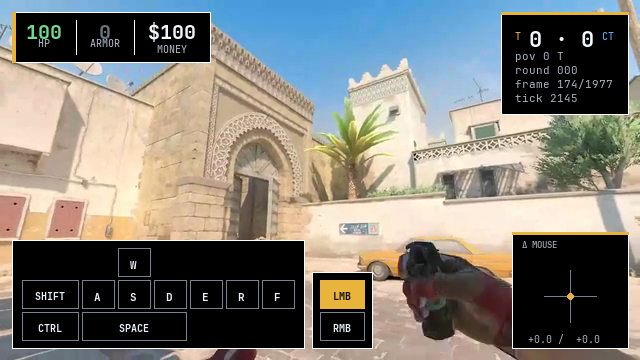

In [6]:
from counterstrike1k import overlay_frame

fire_frames = buttons["FIRE"].nonzero()[0]
frame_idx = int(fire_frames[0]) if len(fire_frames) else len(sample["actions"]) // 2
print(f"showing frame {frame_idx}")
overlay_frame(sample, frame_idx)

For a moving overlay, `overlay_video` writes a debug mp4. This is what to share with collaborators when you're explaining what's in the dataset.

In [7]:
from counterstrike1k import overlay_video

debug_path = Path("data/quickstart") / f"{sample['key']}.debug.mp4"
overlay_video(sample, debug_path, max_frames=192)  # ~6 seconds at 32 FPS
Video(str(debug_path), embed=False, html_attributes="controls")

## 6. Load all 10 POVs of one synchronized round

Every round has exactly 10 synchronized POVs sharing a `round_id`. Group them with the manifest, then pull each one.

In [8]:
rows = pd.DataFrame([{**s["metadata"], "frames_actual": len(s["actions"])} for s in samples])
round_id = rows["round_id"].iloc[0]
round_samples = rows[rows["round_id"] == round_id].sort_values("pov_idx")
print(f"round {round_id}: {len(round_samples)} POVs")
round_samples[["sample_key", "pov_idx", "team_side", "frames_actual", "alive_duration_s"]]

round match_b7638ebe5d27__r000: 10 POVs


,sample_key,pov_idx,team_side,frames_actual,alive_duration_s
0,match_b7638ebe5d27__r000__p00,0,T,1978,61.812500
1,match_b7638ebe5d27__r000__p01,1,CT,1694,51.421875
2,match_b7638ebe5d27__r000__p02,2,CT,1836,55.890625
3,match_b7638ebe5d27__r000__p03,3,CT,1474,44.562500
4,match_b7638ebe5d27__r000__p04,4,CT,1820,55.375000
5,match_b7638ebe5d27__r000__p05,5,CT,1866,56.812500
6,match_b7638ebe5d27__r000__p06,6,T,1978,61.812500
7,match_b7638ebe5d27__r000__p07,7,T,1978,61.812500
8,match_b7638ebe5d27__r000__p08,8,T,1978,61.812500
9,match_b7638ebe5d27__r000__p09,9,T,1046,31.203125


## 7. (Optional) Display all 10 POVs as a grid

Decodes the midpoint frame from each POV and stacks them into a 5×2 grid.

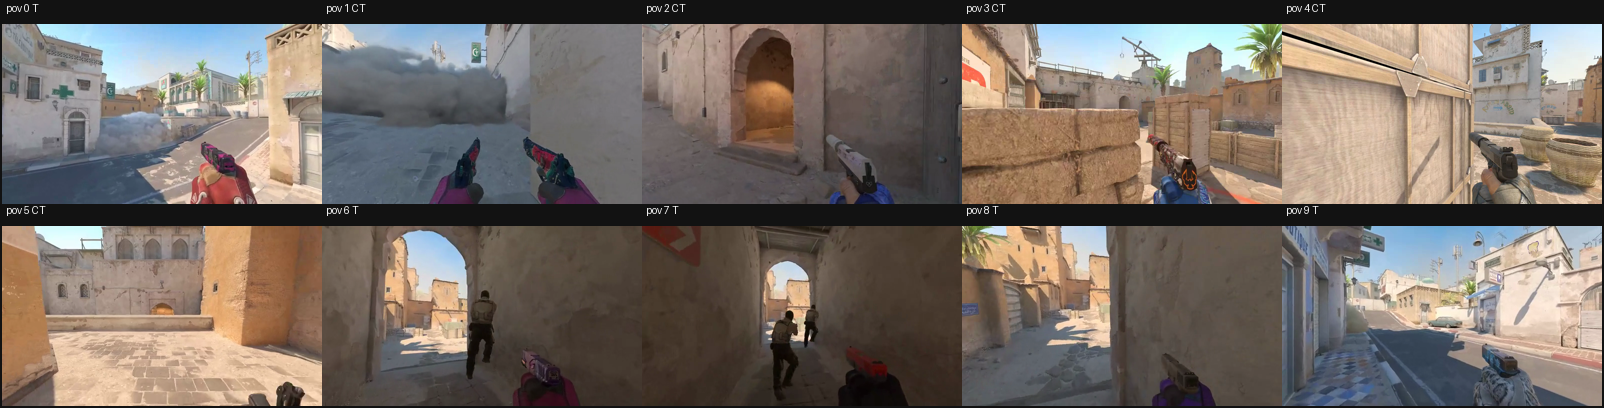

In [9]:
import io
import av
from PIL import Image, ImageDraw

def midpoint_frame(video_bytes):
    with av.open(io.BytesIO(video_bytes)) as container:
        frames = list(container.decode(video=0))
    return frames[len(frames) // 2].to_image()

by_pov = {int(s["metadata"]["pov_idx"]): s for s in samples if s["metadata"]["round_id"] == round_id}
tile_w = 320
tiles = []
for pov in sorted(by_pov):
    img = midpoint_frame(by_pov[pov]["video"])
    th = int(round(tile_w * img.height / img.width))
    tiles.append((pov, by_pov[pov]["metadata"].get("team_side", ""), img.resize((tile_w, th))))

tw, th = tiles[0][2].size
cols, rows_n = 5, 2
grid = Image.new("RGB", (cols * tw + 4, rows_n * (th + 22) + 4), (18, 18, 18))
draw = ImageDraw.Draw(grid)
for i, (pov, side, img) in enumerate(tiles):
    r, c = divmod(i, cols)
    x, y = c * tw + 2, r * (th + 22) + 2
    draw.text((x + 4, y), f"pov {pov} {side}", fill=(245, 245, 245))
    grid.paste(img, (x, y + 22))
grid

## What's next

- For training: stream the **360p** or **720p** WebDataset shards. See `examples/torch_dataset.py`.
- For full schema details: open the [`schema/` folder](https://huggingface.co/datasets/ArnieRamesh/CounterStrike-1K/tree/main/schema) on the dataset card.
- For deeper exploration (parquet+offset access, smoke checks): see `examples/advanced/`.